In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix
!pip install -r requirements.txt
%cd visdom
!pip install -e .
!pip install visdom dominate
%cd /content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix

In [ ]:
import cv2
import pathlib
import glob
import re
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

p_dir = pathlib.Path('/content/drive/My Drive/Colab Notebooks/CycleGAN_Project/pytorch-CycleGAN-and-pix2pix/') #home directory
path = p_dir / 'datasets/T1W2T2W/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations'
from natsort import natsorted

Case_list = []
files = [i for i in path.glob('*[!csv]')]
for file in natsorted(files):
  Case_list.append(file)
  print(file.name)

TCGA-02-0006
TCGA-02-0009
TCGA-02-0011
TCGA-02-0027
TCGA-02-0033
TCGA-02-0034
TCGA-02-0037
TCGA-02-0046
TCGA-02-0047
TCGA-02-0054
TCGA-02-0059
TCGA-02-0064
TCGA-02-0068
TCGA-02-0069
TCGA-02-0070
TCGA-02-0075
TCGA-02-0085
TCGA-02-0086
TCGA-02-0087
TCGA-02-0102
TCGA-02-0106
TCGA-02-0116
TCGA-06-0119
TCGA-06-0122
TCGA-06-0130
TCGA-06-0137
TCGA-06-0138
TCGA-06-0139
TCGA-06-0142
TCGA-06-0145
TCGA-06-0149
TCGA-06-0154
TCGA-06-0158
TCGA-06-0162
TCGA-06-0164
TCGA-06-0176
TCGA-06-0177
TCGA-06-0179
TCGA-06-0182
TCGA-06-0184
TCGA-06-0185
TCGA-06-0187
TCGA-06-0188
TCGA-06-0190
TCGA-06-0192
TCGA-06-0238
TCGA-06-0240
TCGA-06-0644
TCGA-06-0646
TCGA-06-1084
TCGA-06-1802
TCGA-06-2570
TCGA-06-5408
TCGA-06-5413
TCGA-06-5417
TCGA-06-6389
TCGA-08-0355
TCGA-08-0356
TCGA-08-0359
TCGA-08-0360
TCGA-08-0385
TCGA-08-0389
TCGA-08-0390
TCGA-08-0392
TCGA-08-0509
TCGA-08-0512
TCGA-08-0520
TCGA-08-0522
TCGA-12-0616
TCGA-12-0776
TCGA-12-0829
TCGA-12-1094
TCGA-12-1098
TCGA-12-1598
TCGA-12-1601
TCGA-12-3650
TCGA-14-1456

In [ ]:
len(Case_list)

102

In [ ]:
case_ = Case_list[101]

In [ ]:
import os
path = case_ / "T2"
os.makedirs(path / '1-30' / 'testA', exist_ok=True) #T2
os.makedirs(path / '1-30' / 'testB', exist_ok=True) #T1

os.makedirs(path / '31-60' / 'testA', exist_ok=True)
os.makedirs(path / '31-60' / 'testB', exist_ok=True)

os.makedirs(path / '61-90' / 'testA', exist_ok=True)
os.makedirs(path / '61-90' / 'testB', exist_ok=True)

os.makedirs(path / '91-120' / 'testA', exist_ok=True)
os.makedirs(path / '91-120' / 'testB', exist_ok=True)

os.makedirs(path / '121-150' / 'testA', exist_ok=True)
os.makedirs(path / '121-150' / 'testB', exist_ok=True)

os.makedirs(path / '151-155' / 'testA', exist_ok=True)
os.makedirs(path / '151-155' / 'testB', exist_ok=True)

In [ ]:
path = case_
file = [i for i in path.glob('*_t1.nii.gz')]
file[0].name


'TCGA-76-6664_2002.01.10_t1.nii.gz'

In [ ]:
case = path.stem

## radiomics

In [ ]:
!pip install pynrrd
!pip install pyradiomics

In [ ]:
case

'TCGA-76-6664'

In [ ]:
#fake T1 epoch 200
import cv2
import pathlib
import glob
import re
import os
import numpy as np
import matplotlib.pyplot as plt
import nrrd
from PIL import Image

#output dir
path = p_dir / 'datasets/T1W2T2W/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations' / case
#nrrd file name
filename = str(path / 'fake_T2_epoch_200.nrrd')

# Read the data back from file
imagedata, header = nrrd.read(filename)
print(imagedata.shape)
print(header)

(155, 240, 240)
OrderedDict([('type', 'uint8'), ('dimension', 3), ('sizes', array([155, 240, 240])), ('encoding', 'gzip')])


In [ ]:
#output dir
path = p_dir / 'datasets/T1W2T2W/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations' / case
#nrrd file name
filename = str(path / 'real_T2.nrrd')

# Read the data back from file
real_data, header = nrrd.read(filename)
print(real_data.shape)
print(header)

(155, 240, 240)
OrderedDict([('type', 'uint8'), ('dimension', 3), ('sizes', array([155, 240, 240])), ('encoding', 'gzip')])


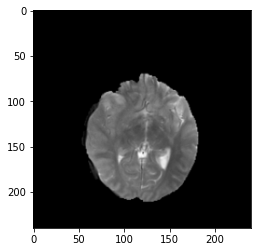

In [ ]:
imagedata[0]
plt.imshow(imagedata[68],cmap='gray')
plt.show()

In [ ]:
filename = str(path / 'contour.nrrd')

# Read the data back from file
contourdata, header = nrrd.read(filename)
print(contourdata.shape)
print(header)

(155, 240, 240)
OrderedDict([('type', 'uint8'), ('dimension', 3), ('sizes', array([155, 240, 240])), ('encoding', 'gzip')])


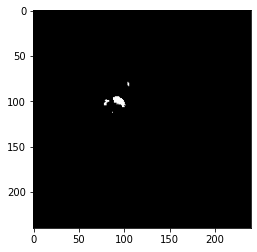

In [ ]:
contourdata[0]
plt.imshow(contourdata[68],cmap='gray')
plt.show()

In [ ]:
import os  # needed navigate the system to get the input data
from radiomics import featureextractor  # This module is used for interaction with pyradiomics
import radiomics
from radiomics import firstorder, getTestCase, glcm, glrlm, glszm, imageoperations, shape, shape2D
import numpy as np
import six

#http://simpleitk.github.io/SimpleITK-Notebooks/01_Image_Basics.html
import SimpleITK as sitk
import matplotlib.pyplot as plt

In [ ]:
%%file params.yaml
imageType:
  Original: {}
  LoG:
    sigma: [2.0, 3.0, 4.0, 5.0]
  Wavelet: {}

featureClass:
  shape:
  firstorder:
  glcm:  # Disable SumAverage by specifying all other GLCM features available
    - 'Autocorrelation'
    - 'JointAverage'
    - 'ClusterProminence'
    - 'ClusterShade'
    - 'ClusterTendency'
    - 'Contrast'
    - 'Correlation'
    - 'DifferenceAverage'
    - 'DifferenceEntropy'
    - 'DifferenceVariance'
    - 'JointEnergy'
    - 'JointEntropy'
    - 'Imc1'
    - 'Imc2'
    - 'Idm'
    - 'Idmn'
    - 'Id'
    - 'Idn'
    - 'InverseVariance'
    - 'MaximumProbability'
    - 'SumEntropy'
    - 'SumSquares'
  glrlm:
  glszm:
  gldm:

setting:
  normalize: true
  normalizeScale: 100  # This allows you to use more or less the same bin width.
  interpolator: 'sitkBSpline'
  resampledPixelSpacing: [2, 2, 2]
  binWidth: 5
  voxelArrayShift: 300
  label: 1

Overwriting params.yaml


In [ ]:
path = p_dir / 'datasets/T1W2T2W/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations/Pre-operative_TCGA_GBM_NIfTI_and_Segmentations' / case
os.makedirs(path / 'CSV', exist_ok=True)

In [ ]:
#real T1 radiomics
real_img = sitk.GetImageFromArray(real_data)
mask_img = sitk.GetImageFromArray(contourdata)

In [ ]:
from radiomics import featureextractor
import pandas as pd
import sys

params = "params.yaml"
extractor = featureextractor.RadiomicsFeatureExtractor(params)
result = extractor.execute(real_img, mask_img)
df = pd.json_normalize(result)
path = path / "CSV"
df.T.to_csv(str(path / 'real_T2.csv'))

In [ ]:
#fake T1 radiomics
taget_img = sitk.GetImageFromArray(imagedata)
mask_img = sitk.GetImageFromArray(contourdata)

In [ ]:
from radiomics import featureextractor
extractor = featureextractor.RadiomicsFeatureExtractor(params)
result = extractor.execute(taget_img, mask_img)
df = pd.json_normalize(result)
df.T.to_csv(str(path / 'fake_T2.csv'))